In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


U ovoj ćeliji učitavamo Breast Cancer Wisconsin dataset iz sklearn biblioteke. Skup podataka sadrži numeričke karakteristike tumora te ciljnu varijablu koja označava je li tumor zloćudan ili dobroćudan.

In [2]:
print(df.info())
print(df.describe())
print("Nedostajuće vrijednosti:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [3]:
X = df.drop("target", axis=1)
y = df["target"]

print("Dimenzije X:", X.shape)
print("Dimenzije y:", y.shape)

Dimenzije X: (569, 30)
Dimenzije y: (569,)


Podatke dijelimo na ulazne varijable (X) i ciljnu varijablu (y). Cilj modela je predvidjeti vrijednost target (0 ili 1).

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

Kreiramo i treniramo model logističke regresije. Model uči kako razlikovati zloćudne i dobroćudne tumore na temelju podataka.

In [7]:
y_pred = log_model.predict(X_test_scaled)

print("Prvih 10 stvarnih:", y_test.values[:10])
print("Prvih 10 predviđenih:", y_pred[:10])

Prvih 10 stvarnih: [1 0 0 1 1 0 0 0 1 1]
Prvih 10 predviđenih: [1 0 0 1 1 0 0 0 1 1]


In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Točnost:", accuracy_score(y_test, y_pred))
print("Matrica zabune:\n", confusion_matrix(y_test, y_pred))
print("Klasifikacijski izvještaj:\n", classification_report(y_test, y_pred))

Točnost: 0.9736842105263158
Matrica zabune:
 [[41  2]
 [ 1 70]]
Klasifikacijski izvještaj:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Koristimo metrike za procjenu modela. Točnost pokazuje koliko je model točan, matrica zabune prikazuje raspodjelu točnih i pogrešnih predikcija, a klasifikacijski izvještaj daje detaljniju analizu.

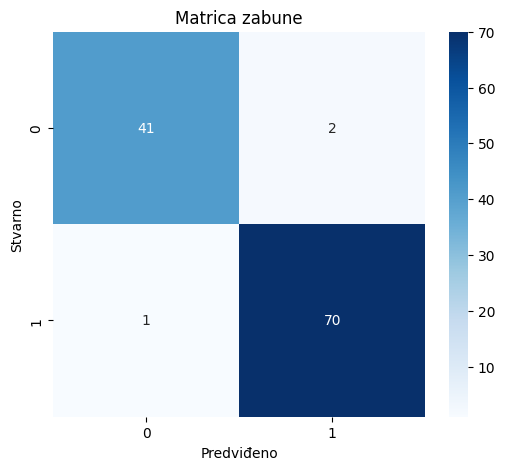

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.title("Matrica zabune")
plt.show()

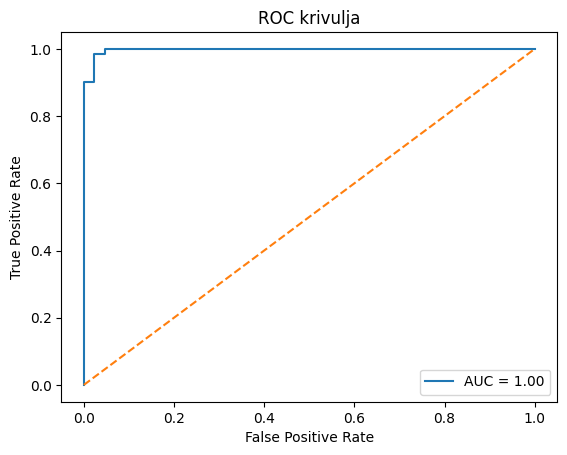

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = log_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krivulja")
plt.legend()
plt.show()

ROC krivulja prikazuje sposobnost modela da razlikuje klase. AUC vrijednost pokazuje kvalitetu modela – što je bliže 1, to je model bolji.

U ovom radu korišten je model logističke regresije za klasifikaciju tumora na zloćudne i dobroćudne koristeći Breast Cancer Wisconsin dataset.
Rezultati pokazuju visoku točnost modela, što znači da model uspješno razlikuje dvije klase. Matrica zabune i klasifikacijski izvještaj potvrđuju dobru preciznost i odziv modela.
ROC krivulja i AUC vrijednost dodatno pokazuju da model ima vrlo dobru sposobnost razlikovanja klasa.

Zaključno, logistička regresija se pokazala kao učinkovit model za ovaj tip klasifikacijskog problema.